# 01 — Points Finish Classification & GLM Modeling

This notebook uses the pre-race feature store for predictive features, the strategy feature store for pit-stop analysis, and the master feature store for race outcome labels

We model four classification targets:

- Points finish (Top 10)
- Podium finish (Top 3)
- DNF probability
- Impact of slow pit stops on podium outcomes

The goal is to demonstrate:
- Generalized linear modeling (logistic regression)
- Tree-based classification methods
- Model calibration
- SHAP-based interpretability
- Temporal validation

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier

import shap
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

We use:
- Pre-race feature store for baseline prediction
- Strategy feature store for pit stop impact analysis

In [2]:
prerace = pd.read_parquet("data_processed/f1_feature_store_prerace.parquet")
strategy = pd.read_parquet("data_processed/f1_feature_store_strategy.parquet")
master = pd.read_parquet("data_processed/f1_feature_store_master.parquet")

df = prerace.copy()

## Define Classification Targets
Create binary outcome variables for:
- points finish
- podium finish
- DNF probability

In [3]:
# merge DNF target from master store
df = df.merge(
    master[["raceId", "driverId", "is_dnf"]],
    on=["raceId", "driverId"],
    how="left"
)

df["target_points"] = (df["finish_position"] <= 10).astype(int)
df["target_podium"] = (df["finish_position"] <= 3).astype(int)
df["target_dnf"] = df["is_dnf"].fillna(0).astype(int)

## Merge Strategy Data

Merge selected race-level pit stop features from the strategy feature store to support exploratory analysis of pit stop timing and duration.

In [4]:
strategy_cols = [
    "raceId",
    "driverId",
    "pit_stop_count",
    "avg_pit_stop_ms"
]

df = df.merge(
    strategy[strategy_cols],
    on=["raceId", "driverId"],
    how="left"
)

## Define Slow Pit Stop Indicator

Create a binary indicator for whether a driver's average pit stop duration falls in the slowest quartile of observed pit stop durations.

In [5]:
threshold = df["avg_pit_stop_ms"].quantile(0.75)
df["slow_pit_stop"] = (df["avg_pit_stop_ms"] > threshold).astype(int)

In [6]:
threshold
df["slow_pit_stop"].value_counts(dropna=False)

slow_pit_stop
0    25983
1     1394
Name: count, dtype: int64

## Inspect Target Balance

Review class balance for each classification target before modeling.

In [7]:
target_summary = pd.DataFrame({
    "target": ["Points Finish", "Podium Finish", "DNF"],
    "positive_rate": [
        df["target_podium"].mean(),
        df["target_podium"].mean(),
        df["target_dnf"].mean()
    ]
})

target_summary

,target,positive_rate
0,Points Finish,0.422873
1,Podium Finish,0.127077
2,DNF,0.443182


## Select Features

Define the pre-race feature set used for the classification models.

In [8]:
features_cls = [
    "grid_clean",
    "qualifying_position",
    "best_qualifying_time_ms",
    "made_q2",
    "made_q3",
    "driver_avg_finish_last5",
    "driver_podium_last5",
    "driver_dnf_rate_last5",
    "driver_avg_grid_last5",
    "constructor_points_last5",
    "constructor_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "driver_standing_points_prerace",
    "driver_standing_position_prerace",
    "driver_standing_wins_prerace",
    "constructor_standing_points_prerace",
    "constructor_standing_position_prerace",
    "constructor_standing_wins_prerace",
    "alt",
    "abs_lat",
    "temp_avg",
    "temp_range",
    "precipitation",
    "humidity_avg",
    "wind_speed",
    "is_wet_race",
    "high_altitude_track",
    "year"
]

In [9]:
missing_summary_cls = (
    df[["target_points", "target_podium", "target_dnf"] + features_cls]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_pct")
)

missing_summary_cls

,missing_pct
best_qualifying_time_ms,1.000000
qualifying_position,0.616686
made_q2,0.616686
made_q3,0.616686
driver_avg_grid_last5,0.235453
driver_avg_finish_last5,0.122365
driver_points_last5,0.122365
driver_dnf_rate_last5,0.122365
constructor_standing_wins_prerace,0.098331
constructor_standing_position_prerace,0.098331


## Core Classification Feature Set

To preserve sample coverage and avoid losing observations due to missing values in more specialized variables, the initial classification models use a core pre-race feature set with broad historical coverage.

More detailed qualifying-session and standings variables can be evaluated in later specifications.

In [10]:
features_cls_core = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_points_last5",
    "driver_dnf_rate_last5",
    "driver_avg_grid_last5",
    "constructor_points_last5",
    "constructor_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "alt",
    "abs_lat",
    "temp_avg",
    "temp_range",
    "precipitation",
    "humidity_avg",
    "wind_speed",
    "is_wet_race",
    "high_altitude_track",
    "year"
]

In [11]:
model_df = df[
    ["raceId", "driverId", "target_points", "target_podium", "target_dnf"] + features_cls_core
].copy()

for col in model_df.columns:
    if col not in ["raceId", "driverId"]:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna().copy()

model_df.shape

(9297, 24)

## Temporal Train/Test Split

Split the modeling dataset into historical training data and recent test data using year-based separation.

In [12]:
model_df["year"] = pd.to_numeric(model_df["year"], errors="coerce")

train = model_df[model_df["year"] <= 2021].copy()
test = model_df[model_df["year"] >= 2022].copy()

X_train = train[features_cls_core]
X_test = test[features_cls_core]

X_train.shape, X_test.shape

((8202, 19), (1095, 19))

## GLM 1: Predicting Points Finish

Fit a logistic regression model to estimate the probability that a driver finishes in the points.

In [13]:
y_train_points = train["target_points"]
y_test_points = test["target_points"]

logit_points = LogisticRegression(max_iter=1000)
logit_points.fit(X_train, y_train_points)

probs_points = logit_points.predict_proba(X_test)[:, 1]
auc_points = roc_auc_score(y_test_points, probs_points)

auc_points

/Users/paigeblackstone/projects/f1-worldchamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.871183058659124

### Model Interpretation — Points Finish (Logistic Regression)

Logistic regression coefficients represent the change in log-odds associated with a one-unit increase in each feature.

Positive coefficients increase the probability of finishing in the points, while negative coefficients decrease it.

This provides a transparent view into how pre-race factors influence race outcomes.

In [14]:
coef_df = pd.DataFrame({
    "feature": features_cls_core,
    "coef": logit_points.coef_[0]
}).sort_values(by="coef", ascending=False)

coef_df

,feature,coef
7,constructor_dnf_rate_last5,0.441091
4,driver_dnf_rate_last5,0.329334
6,constructor_points_last5,0.004385
3,driver_points_last5,0.002693
18,year,0.001378
15,wind_speed,0.000455
9,alt,0.000007
10,abs_lat,-0.001039
14,humidity_avg,-0.001320
11,temp_avg,-0.002645


Exponentiating coefficients provides odds ratios, which are easier to interpret.

For example:
- An odds ratio > 1 increases the likelihood of a points finish
- An odds ratio < 1 decreases the likelihood

In [15]:
coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df

,feature,coef,odds_ratio
7,constructor_dnf_rate_last5,0.441091,1.554401
4,driver_dnf_rate_last5,0.329334,1.390042
6,constructor_points_last5,0.004385,1.004395
3,driver_points_last5,0.002693,1.002697
18,year,0.001378,1.001379
15,wind_speed,0.000455,1.000455
9,alt,0.000007,1.000007
10,abs_lat,-0.001039,0.998962
14,humidity_avg,-0.001320,0.998681
11,temp_avg,-0.002645,0.997358


### Calibration Interpretation

A well-calibrated model produces predicted probabilities that closely align with observed outcomes.

Deviations from the diagonal indicate overconfidence or underconfidence in predictions.

Calibration is particularly important in probabilistic models used for decision-making.

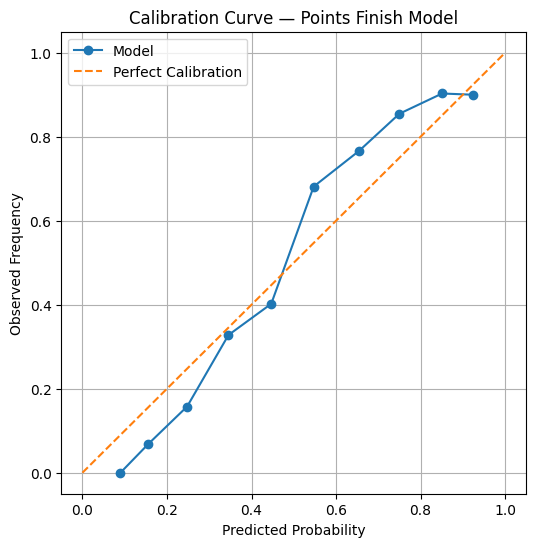

In [16]:
prob_true, prob_pred = calibration_curve(y_test_points, probs_points, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.title("Calibration Curve — Points Finish Model")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.legend()
plt.grid(True)
plt.show()

### Lift Interpretation

The lift chart demonstrates how effectively the model ranks drivers by likelihood of finishing in the points.

Higher deciles should show higher observed points-finish rates, indicating strong ranking performance.

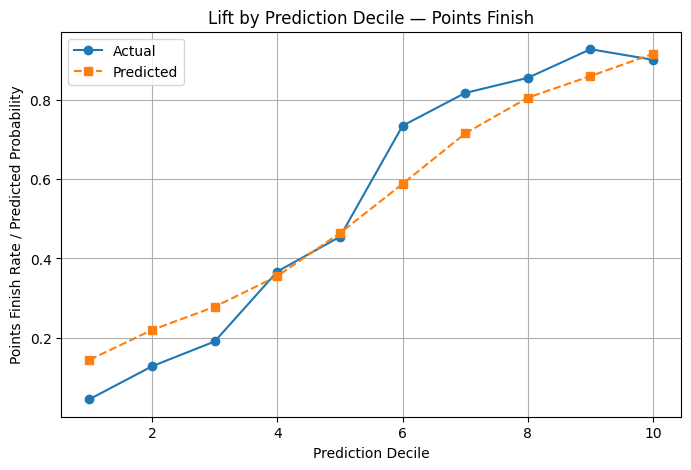

In [17]:
lift_df = test.copy()
lift_df["pred_points_prob"] = probs_points

lift_df["score_decile"] = pd.qcut(
    lift_df["pred_points_prob"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

decile_perf = (
    lift_df.groupby("score_decile")
    .agg(
        actual_points_rate=("target_points", "mean"),
        avg_pred_prob=("pred_points_prob", "mean"),
        n=("target_points", "size")
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(decile_perf["score_decile"], decile_perf["actual_points_rate"], marker="o", label="Actual")
plt.plot(decile_perf["score_decile"], decile_perf["avg_pred_prob"], marker="s", linestyle="--", label="Predicted")
plt.title("Lift by Prediction Decile — Points Finish")
plt.xlabel("Prediction Decile")
plt.ylabel("Points Finish Rate / Predicted Probability")
plt.legend()
plt.grid(True)
plt.show()

## Tree-Based Classifier

Fit an XGBoost classifier for points-finish prediction to compare against the logistic regression baseline.

In [18]:
xgb_points = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_points.fit(X_train, y_train_points)

probs_points_xgb = xgb_points.predict_proba(X_test)[:, 1]
auc_points_xgb = roc_auc_score(y_test_points, probs_points_xgb)

auc_points_xgb

0.8686031590333438

## Model Comparison

Compare the logistic regression and XGBoost points-finish models using ROC-AUC.

In [19]:
model_compare = pd.DataFrame({
    "model": ["Logistic Regression", "XGBoost"],
    "roc_auc": [auc_points, auc_points_xgb]
})

model_compare

,model,roc_auc
0,Logistic Regression,0.871183
1,XGBoost,0.868603


## SHAP Analysis

Use SHAP values to interpret feature contributions in the tree-based points-finish model.

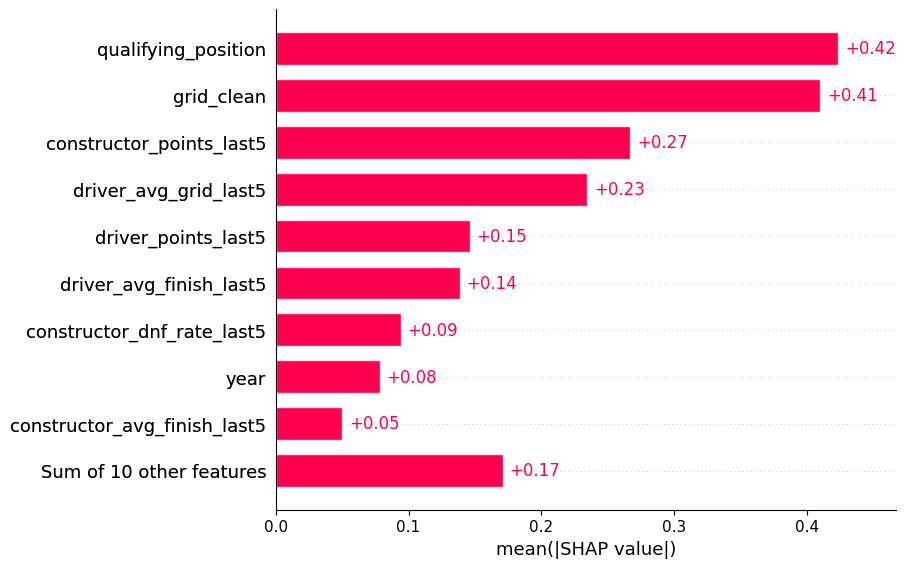

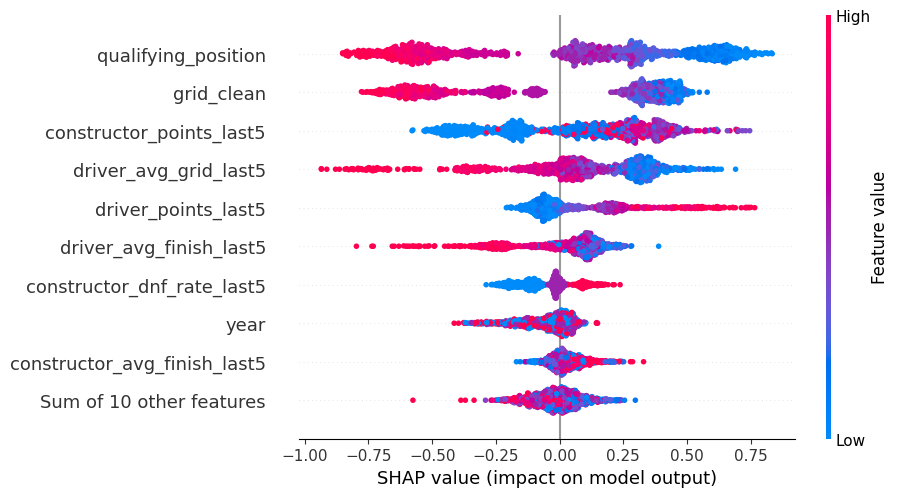

In [20]:
explainer = shap.Explainer(xgb_points)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)

## Slow Pit Stop Impact Summaries

Summarize the relationship between slow pit stops and podium outcomes at the overall, driver, and constructor levels.

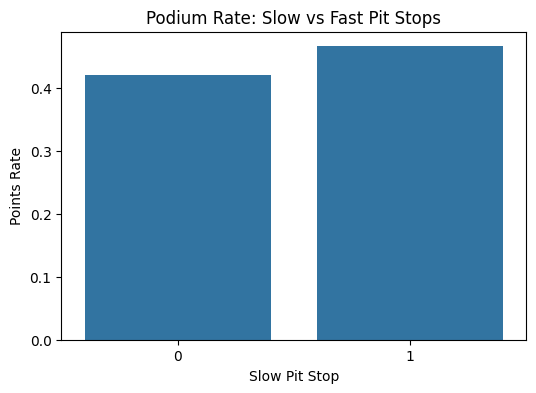

In [21]:
pit_effect = (
    df.groupby("slow_pit_stop")["target_points"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))
sns.barplot(data=pit_effect, x="slow_pit_stop", y="target_points")
plt.title("Podium Rate: Slow vs Fast Pit Stops")
plt.xlabel("Slow Pit Stop")
plt.ylabel("Points Rate")
plt.show()

driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_points"]
    .mean()
    .reset_index()
)

In [22]:
driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_points"]
    .mean()
    .reset_index()
)

driver_pit.head()

,driverId,slow_pit_stop,target_points
0,1,0,0.865320
1,1,1,0.932203
2,2,0,0.548913
3,3,0,0.687831
4,3,1,0.823529


In [23]:
team_pit = (
    df.groupby(["constructorId", "slow_pit_stop"])["target_points"]
    .mean()
    .reset_index()
)

team_pit.head()

,constructorId,slow_pit_stop,target_points
0,1,0,0.606943
1,1,1,0.642336
2,2,0,0.650000
3,3,0,0.485046
4,3,1,0.210145


## Export Visuals to PDF

Save all classification-model visuals to a single labeled PDF for reporting, portfolio use, and article integration.

In [26]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("data_processed/figures", exist_ok=True)

pdf_path = "data_processed/figures/01_points_finish_classification_visuals_points.pdf"

with PdfPages(pdf_path) as pdf:

    # 1. Calibration Curve — Points Finish
    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred, prob_true, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.title("01. Calibration Curve — Points Finish Model", fontsize=14, weight="bold")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 2. Lift by Decile — Points Finish
    plt.figure(figsize=(8, 5))
    plt.plot(decile_perf["score_decile"], decile_perf["actual_points_rate"], marker="o", label="Actual")
    plt.plot(decile_perf["score_decile"], decile_perf["avg_pred_prob"], marker="s", linestyle="--", label="Predicted")
    plt.title("02. Lift by Prediction Decile — Points Finish", fontsize=14, weight="bold")
    plt.xlabel("Prediction Decile")
    plt.ylabel("Points Finish Rate / Predicted Probability")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 3. SHAP Bar Plot — XGBoost Points Finish
    # This recreates the figure in a way PdfPages can save consistently
    shap.plots.bar(shap_values, show=False)
    plt.title("03. SHAP Feature Importance — XGBoost Points Finish", fontsize=14, weight="bold")
    plt.tight_layout()
    pdf.savefig(plt.gcf())
    plt.close()

    # 4. SHAP Beeswarm — XGBoost Points Finish
    shap.plots.beeswarm(shap_values, show=False)
    plt.title("04. SHAP Beeswarm — XGBoost Points Finish", fontsize=14, weight="bold")
    plt.tight_layout()
    pdf.savefig(plt.gcf())
    plt.close()

    # 5. Podium Probability: Slow vs Fast Pit Stops
    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=df,
        x="slow_pit_stop",
        y="target_points",
        errorbar="ci"
    )
    plt.title("05. Points Probability — Slow vs Fast Pit Stops", fontsize=14, weight="bold")
    plt.xlabel("Slow Pit Stop")
    plt.ylabel("Points Rate")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 6. Points Model Comparison Table as Figure
    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.axis("off")
    ax.table(
        cellText=model_compare.round(4).values,
        colLabels=model_compare.columns,
        loc="center"
    )
    plt.title("07. Points Finish Model Comparison", fontsize=14, weight="bold", pad=12)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 7. Logistic Coefficients / Odds Ratios Table if available
    if "coef_df" in locals():
        coef_export = coef_df.copy()
        if "odds_ratio" not in coef_export.columns:
            coef_export["odds_ratio"] = np.exp(coef_export["coef"])

        fig, ax = plt.subplots(figsize=(10, min(12, 0.35 * len(coef_export) + 1.5)))
        ax.axis("off")
        ax.table(
            cellText=coef_export.round(4).values,
            colLabels=coef_export.columns,
            loc="center"
        )
        plt.title("08. Logistic Regression Coefficients and Odds Ratios", fontsize=14, weight="bold", pad=12)
        plt.tight_layout()
        pdf.savefig()
        plt.close()

print(f"Saved PDF to: {pdf_path}")

Saved PDF to: data_processed/figures/01_points_finish_classification_visuals_points.pdf


## GLM 2: Predicting Podium Finish

Fit a logistic regression model to estimate the probability that a driver finishes on the podium.

In [27]:
y_train_podium = train["target_podium"]
y_test_podium = test["target_podium"]

logit_podium = LogisticRegression(max_iter=1000)
logit_podium.fit(X_train, y_train_podium)

probs_podium = logit_podium.predict_proba(X_test)[:, 1]
auc_podium = roc_auc_score(y_test_podium, probs_podium)

auc_podium

/Users/paigeblackstone/projects/f1-worldchamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9255084566844166

In [29]:
coef_df = pd.DataFrame({
    "feature": features_cls_core,
    "coef": logit_podium.coef_[0]
}).sort_values(by="coef", ascending=False)

coef_df

,feature,coef
7,constructor_dnf_rate_last5,0.657966
4,driver_dnf_rate_last5,0.654287
17,high_altitude_track,0.035139
16,is_wet_race,0.024038
3,driver_points_last5,0.012736
11,temp_avg,0.012511
13,precipitation,0.004098
10,abs_lat,0.003417
18,year,0.000728
9,alt,-0.000104


In [30]:
coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df

,feature,coef,odds_ratio
7,constructor_dnf_rate_last5,0.657966,1.930861
4,driver_dnf_rate_last5,0.654287,1.923771
17,high_altitude_track,0.035139,1.035764
16,is_wet_race,0.024038,1.024330
3,driver_points_last5,0.012736,1.012818
11,temp_avg,0.012511,1.012589
13,precipitation,0.004098,1.004107
10,abs_lat,0.003417,1.003422
18,year,0.000728,1.000729
9,alt,-0.000104,0.999896


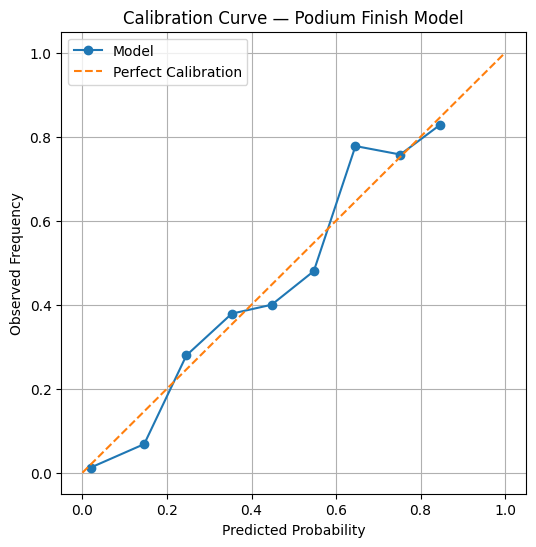

In [31]:
prob_true, prob_pred = calibration_curve(y_test_podium, probs_podium, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.title("Calibration Curve — Podium Finish Model")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.legend()
plt.grid(True)
plt.show()

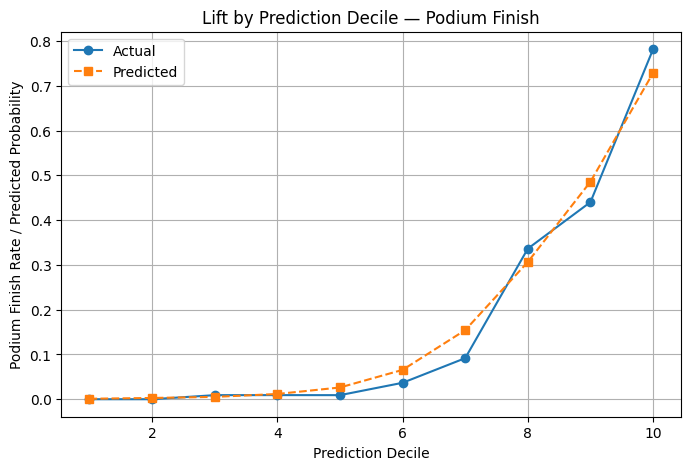

In [32]:
lift_df = test.copy()
lift_df["pred_podium_prob"] = probs_podium

lift_df["podium_decile"] = pd.qcut(
    lift_df["pred_podium_prob"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

decile_perf = (
    lift_df.groupby("podium_decile")
    .agg(
        actual_podium_rate=("target_podium", "mean"),
        avg_pred_prob=("pred_podium_prob", "mean"),
        n=("target_podium", "size")
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(decile_perf["podium_decile"], decile_perf["actual_podium_rate"], marker="o", label="Actual")
plt.plot(decile_perf["podium_decile"], decile_perf["avg_pred_prob"], marker="s", linestyle="--", label="Predicted")
plt.title("Lift by Prediction Decile — Podium Finish")
plt.xlabel("Prediction Decile")
plt.ylabel("Podium Finish Rate / Predicted Probability")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
xgb_podium = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_podium.fit(X_train, y_train_podium)

probs_podium_xgb = xgb_podium.predict_proba(X_test)[:, 1]
auc_podium_xgb = roc_auc_score(y_test_podium, probs_podium_xgb)

auc_podium_xgb

0.9279598395458492

In [34]:
model_compare = pd.DataFrame({
    "model": ["Logistic Regression", "XGBoost"],
    "roc_auc": [auc_podium, auc_podium_xgb]
})

model_compare

,model,roc_auc
0,Logistic Regression,0.925508
1,XGBoost,0.927960


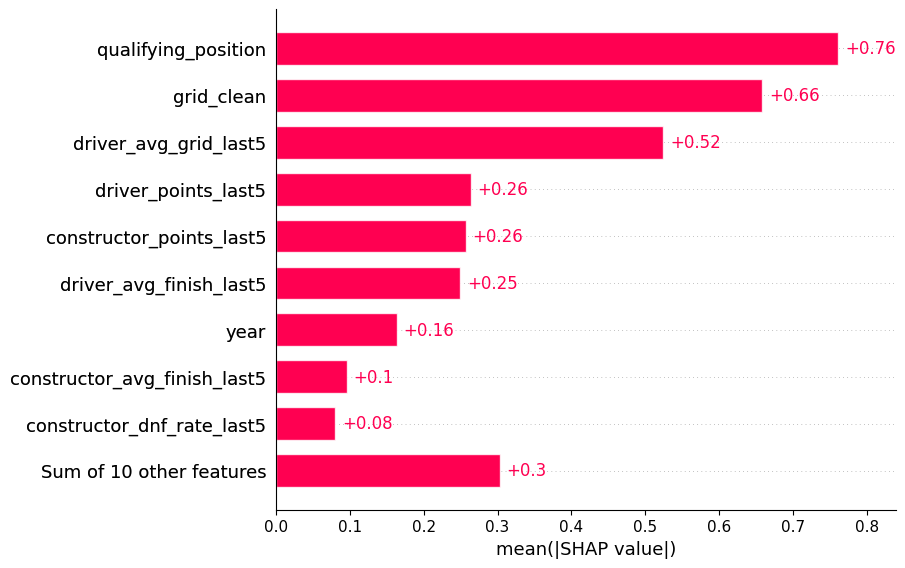

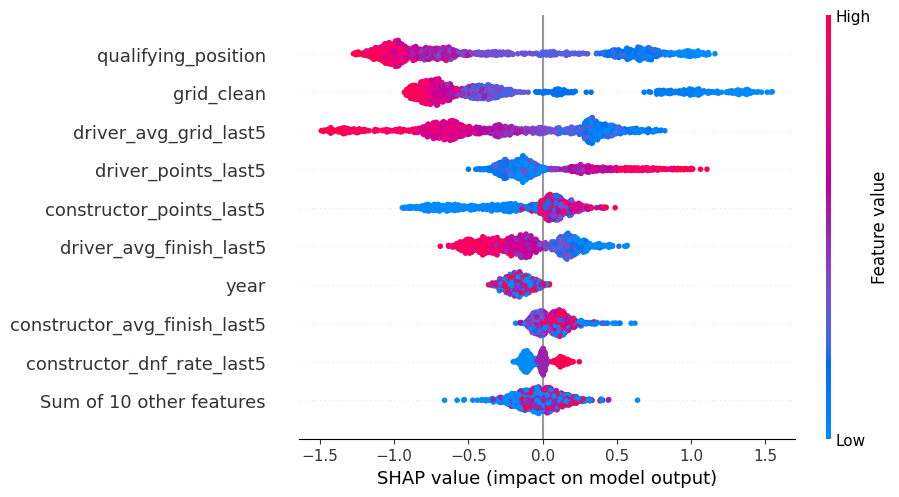

In [35]:
explainer = shap.Explainer(xgb_podium)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)

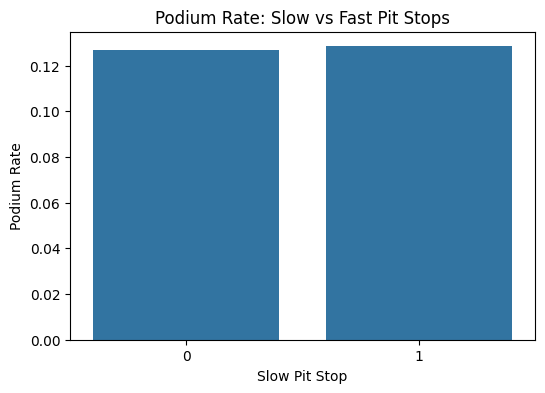

In [36]:
pit_effect = (
    df.groupby("slow_pit_stop")["target_podium"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))
sns.barplot(data=pit_effect, x="slow_pit_stop", y="target_podium")
plt.title("Podium Rate: Slow vs Fast Pit Stops")
plt.xlabel("Slow Pit Stop")
plt.ylabel("Podium Rate")
plt.show()

driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_podium"]
    .mean()
    .reset_index()
)

In [37]:
driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_podium"]
    .mean()
    .reset_index()
)

driver_pit.head()

,driverId,slow_pit_stop,target_podium
0,1,0,0.555556
1,1,1,0.627119
2,2,0,0.070652
3,3,0,0.253968
4,3,1,0.529412


In [38]:
team_pit = (
    df.groupby(["constructorId", "slow_pit_stop"])["target_podium"]
    .mean()
    .reset_index()
)

team_pit.head()

,constructorId,slow_pit_stop,target_podium
0,1,0,0.276596
1,1,1,0.102190
2,2,0,0.121429
3,3,0,0.202211
4,3,1,0.021739


In [40]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("data_processed/figures", exist_ok=True)

pdf_path = "data_processed/figures/01_points_finish_classification_visuals_podium.pdf"

with PdfPages(pdf_path) as pdf:

    # 1. Calibration Curve — Podium Finish
    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred, prob_true, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.title("01. Calibration Curve — Podium Finish Model", fontsize=14, weight="bold")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 2. Lift by Decile — Podium Finish
    plt.figure(figsize=(8, 5))
    plt.plot(decile_perf["podium_decile"], decile_perf["actual_podium_rate"], marker="o", label="Actual")
    plt.plot(decile_perf["podium_decile"], decile_perf["avg_pred_prob"], marker="s", linestyle="--", label="Predicted")
    plt.title("02. Lift by Prediction Decile — Podium Finish", fontsize=14, weight="bold")
    plt.xlabel("Prediction Decile")
    plt.ylabel("Podium Finish Rate / Predicted Probability")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 3. SHAP Bar Plot — XGBoost Podium Finish
    # This recreates the figure in a way PdfPages can save consistently
    shap.plots.bar(shap_values, show=False)
    plt.title("03. SHAP Feature Importance — XGBoost Podium Finish", fontsize=14, weight="bold")
    plt.tight_layout()
    pdf.savefig(plt.gcf())
    plt.close()

    # 4. SHAP Beeswarm — XGBoost Points Finish
    shap.plots.beeswarm(shap_values, show=False)
    plt.title("04. SHAP Beeswarm — XGBoost Podium Finish", fontsize=14, weight="bold")
    plt.tight_layout()
    pdf.savefig(plt.gcf())
    plt.close()

    # 5. Podium Probability: Slow vs Fast Pit Stops
    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=df,
        x="slow_pit_stop",
        y="target_podium",
        errorbar="ci"
    )
    plt.title("05. Podium Probability — Slow vs Fast Pit Stops", fontsize=14, weight="bold")
    plt.xlabel("Slow Pit Stop")
    plt.ylabel("Podium Rate")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 6. Points Model Comparison Table as Figure
    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.axis("off")
    ax.table(
        cellText=model_compare.round(4).values,
        colLabels=model_compare.columns,
        loc="center"
    )
    plt.title("07. Podium Finish Model Comparison", fontsize=14, weight="bold", pad=12)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 7. Logistic Coefficients / Odds Ratios Table if available
    if "coef_df" in locals():
        coef_export = coef_df.copy()
        if "odds_ratio" not in coef_export.columns:
            coef_export["odds_ratio"] = np.exp(coef_export["coef"])

        fig, ax = plt.subplots(figsize=(10, min(12, 0.35 * len(coef_export) + 1.5)))
        ax.axis("off")
        ax.table(
            cellText=coef_export.round(4).values,
            colLabels=coef_export.columns,
            loc="center"
        )
        plt.title("08. Logistic Regression Coefficients and Odds Ratios", fontsize=14, weight="bold", pad=12)
        plt.tight_layout()
        pdf.savefig()
        plt.close()

print(f"Saved PDF to: {pdf_path}")

Saved PDF to: data_processed/figures/01_points_finish_classification_visuals_podium.pdf


## GLM 3: Predicting DNF Probability

Fit a logistic regression model to estimate the probability that a driver does not finish the race.

In [41]:
y_train_dnf = train["target_dnf"]
y_test_dnf = test["target_dnf"]

logit_dnf = LogisticRegression(max_iter=1000)
logit_dnf.fit(X_train, y_train_dnf)

probs_dnf = logit_dnf.predict_proba(X_test)[:, 1]
auc_dnf = roc_auc_score(y_test_dnf, probs_dnf)

auc_dnf

/Users/paigeblackstone/projects/f1-worldchamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.573510944947059

In [42]:
coef_df = pd.DataFrame({
    "feature": features_cls_core,
    "coef": logit_dnf.coef_[0]
}).sort_values(by="coef", ascending=False)

coef_df

,feature,coef
7,constructor_dnf_rate_last5,1.062341
4,driver_dnf_rate_last5,1.036861
17,high_altitude_track,0.129532
16,is_wet_race,0.097990
5,driver_avg_grid_last5,0.045284
12,temp_range,0.022779
1,qualifying_position,0.016904
0,grid_clean,0.010121
13,precipitation,0.003826
14,humidity_avg,0.003121


In [43]:
coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df

,feature,coef,odds_ratio
7,constructor_dnf_rate_last5,1.062341,2.893136
4,driver_dnf_rate_last5,1.036861,2.820351
17,high_altitude_track,0.129532,1.138295
16,is_wet_race,0.097990,1.102952
5,driver_avg_grid_last5,0.045284,1.046325
12,temp_range,0.022779,1.023040
1,qualifying_position,0.016904,1.017047
0,grid_clean,0.010121,1.010173
13,precipitation,0.003826,1.003833
14,humidity_avg,0.003121,1.003125


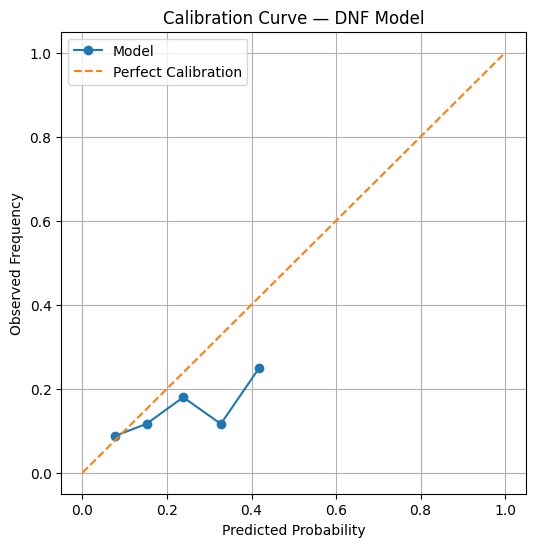

In [44]:
prob_true, prob_pred = calibration_curve(y_test_dnf, probs_dnf, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.title("Calibration Curve — DNF Model")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.legend()
plt.grid(True)
plt.show()

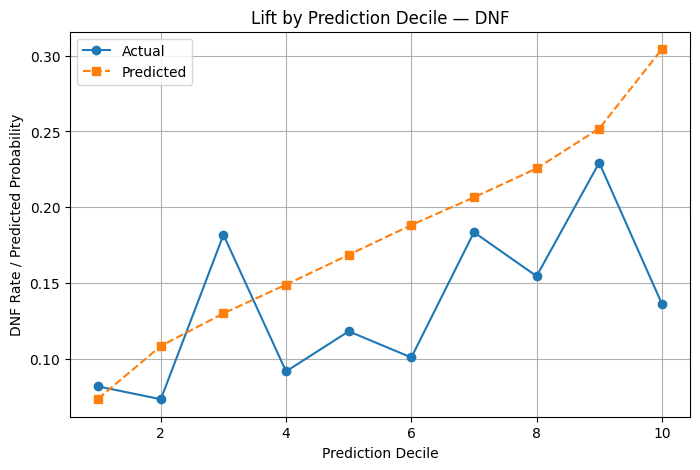

In [45]:
lift_df = test.copy()
lift_df["pred_dnf_prob"] = probs_dnf

lift_df["dnf_decile"] = pd.qcut(
    lift_df["pred_dnf_prob"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

decile_perf = (
    lift_df.groupby("dnf_decile")
    .agg(
        actual_dnf_rate=("target_dnf", "mean"),
        avg_pred_prob=("pred_dnf_prob", "mean"),
        n=("target_dnf", "size")
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(decile_perf["dnf_decile"], decile_perf["actual_dnf_rate"], marker="o", label="Actual")
plt.plot(decile_perf["dnf_decile"], decile_perf["avg_pred_prob"], marker="s", linestyle="--", label="Predicted")
plt.title("Lift by Prediction Decile — DNF")
plt.xlabel("Prediction Decile")
plt.ylabel("DNF Rate / Predicted Probability")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
xgb_dnf = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_dnf.fit(X_train, y_train_dnf)

probs_dnf_xgb = xgb_dnf.predict_proba(X_test)[:, 1]
auc_dnf_xgb = roc_auc_score(y_test_dnf, probs_dnf_xgb)

auc_dnf_xgb

0.5644496132880504

In [47]:
model_compare = pd.DataFrame({
    "model": ["Logistic Regression", "XGBoost"],
    "roc_auc": [auc_dnf, auc_dnf_xgb]
})

model_compare

,model,roc_auc
0,Logistic Regression,0.573511
1,XGBoost,0.564450


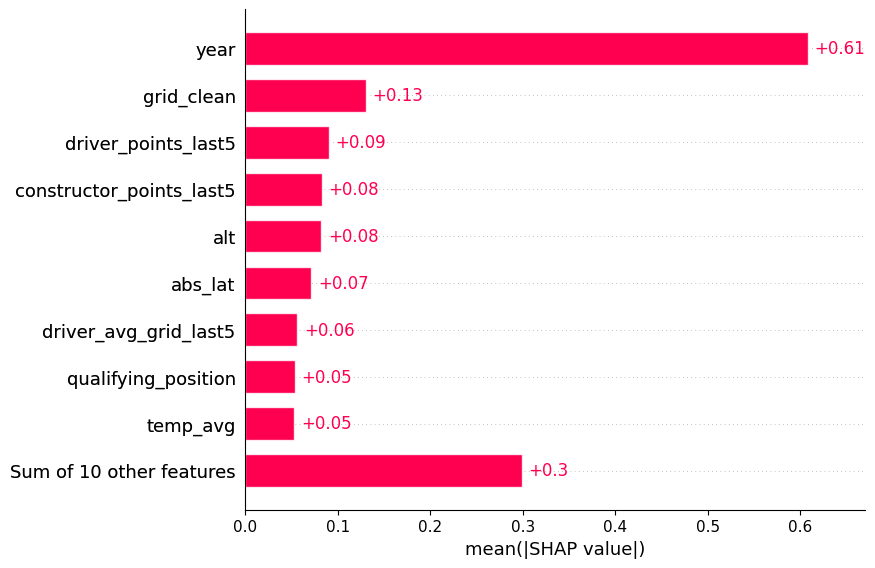

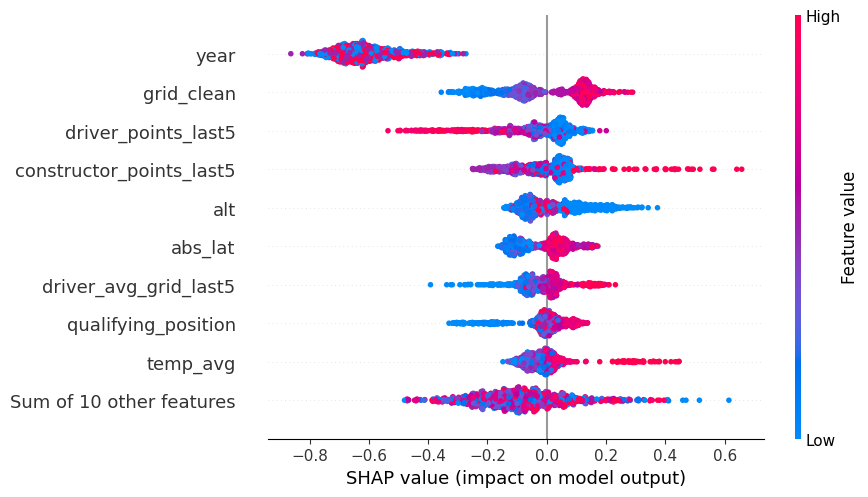

In [48]:
explainer = shap.Explainer(xgb_dnf)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)

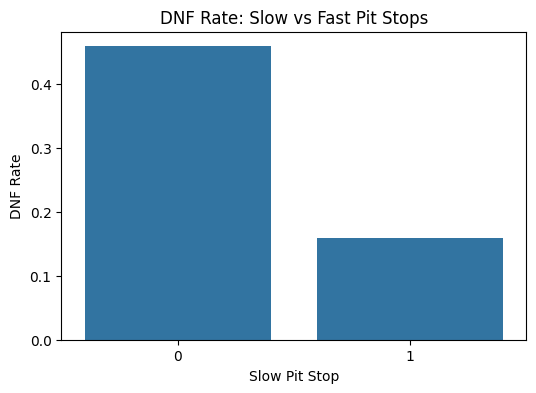

In [49]:
pit_effect = (
    df.groupby("slow_pit_stop")["target_dnf"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))
sns.barplot(data=pit_effect, x="slow_pit_stop", y="target_dnf")
plt.title("DNF Rate: Slow vs Fast Pit Stops")
plt.xlabel("Slow Pit Stop")
plt.ylabel("DNF Rate")
plt.show()

driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_dnf"]
    .mean()
    .reset_index())

In [50]:
driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_dnf"]
    .mean()
    .reset_index())

team_pit = (
    df.groupby(["constructorId", "slow_pit_stop"])["target_dnf"]
    .mean()
    .reset_index()
)

team_pit.head()

,constructorId,slow_pit_stop,target_dnf
0,1,0,0.324188
1,1,1,0.109489
2,2,0,0.164286
3,3,0,0.314694
4,3,1,0.210145


In [51]:
driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_dnf"]
    .mean()
    .reset_index()
)

driver_pit.head()

,driverId,slow_pit_stop,target_dnf
0,1,0,0.107744
1,1,1,0.033898
2,2,0,0.266304
3,3,0,0.153439
4,3,1,0.117647


In [52]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("data_processed/figures", exist_ok=True)

pdf_path = "data_processed/figures/01_points_finish_classification_visuals_DNF.pdf"

with PdfPages(pdf_path) as pdf:

    # 1. Calibration Curve — DNF
    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred, prob_true, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.title("01. Calibration Curve — DNF Model", fontsize=14, weight="bold")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 2. Lift by Decile — DNF
    plt.figure(figsize=(8, 5))
    plt.plot(decile_perf["dnf_decile"], decile_perf["actual_dnf_rate"], marker="o", label="Actual")
    plt.plot(decile_perf["dnf_decile"], decile_perf["avg_pred_prob"], marker="s", linestyle="--", label="Predicted")
    plt.title("02. Lift by Prediction Decile — DNF", fontsize=14, weight="bold")
    plt.xlabel("Prediction Decile")
    plt.ylabel("DNF Rate / Predicted Probability")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 3. SHAP Bar Plot — XGBoost Podium Finish
    # This recreates the figure in a way PdfPages can save consistently
    shap.plots.bar(shap_values, show=False)
    plt.title("03. SHAP Feature Importance — XGBoost DNF", fontsize=14, weight="bold")
    plt.tight_layout()
    pdf.savefig(plt.gcf())
    plt.close()

    # 4. SHAP Beeswarm — XGBoost Points Finish
    shap.plots.beeswarm(shap_values, show=False)
    plt.title("04. SHAP Beeswarm — XGBoost DNF", fontsize=14, weight="bold")
    plt.tight_layout()
    pdf.savefig(plt.gcf())
    plt.close()

    # 5. Podium Probability: Slow vs Fast Pit Stops
    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=df,
        x="slow_pit_stop",
        y="target_dnf",
        errorbar="ci"
    )
    plt.title("05. DNF Probability — Slow vs Fast Pit Stops", fontsize=14, weight="bold")
    plt.xlabel("Slow Pit Stop")
    plt.ylabel("DNF Rate")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 6. Points Model Comparison Table as Figure
    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.axis("off")
    ax.table(
        cellText=model_compare.round(4).values,
        colLabels=model_compare.columns,
        loc="center"
    )
    plt.title("07. DNF Model Comparison", fontsize=14, weight="bold", pad=12)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 7. Logistic Coefficients / Odds Ratios Table if available
    if "coef_df" in locals():
        coef_export = coef_df.copy()
        if "odds_ratio" not in coef_export.columns:
            coef_export["odds_ratio"] = np.exp(coef_export["coef"])

        fig, ax = plt.subplots(figsize=(10, min(12, 0.35 * len(coef_export) + 1.5)))
        ax.axis("off")
        ax.table(
            cellText=coef_export.round(4).values,
            colLabels=coef_export.columns,
            loc="center"
        )
        plt.title("08. Logistic Regression Coefficients and Odds Ratios", fontsize=14, weight="bold", pad=12)
        plt.tight_layout()
        pdf.savefig()
        plt.close()

print(f"Saved PDF to: {pdf_path}")

Saved PDF to: data_processed/figures/01_points_finish_classification_visuals_DNF.pdf


## GLM 4: Slow Pit Stop and Podium Finish

Fit an exploratory logistic regression model to test whether slow pit stops are associated with lower podium probability.

This section uses race-level pit stop information and is intended as an exploratory extension rather than a pure pre-race prediction task.

In [53]:
pit_df = df[["raceId", "driverId", "target_podium", "slow_pit_stop"] + features_cls_core].copy()

for col in pit_df.columns:
    if col not in ["raceId", "driverId"]:
        pit_df[col] = pd.to_numeric(pit_df[col], errors="coerce")

pit_df = pit_df.dropna().copy()

train_pit = pit_df[pit_df["year"] <= 2021].copy()
test_pit = pit_df[pit_df["year"] >= 2022].copy()

features_pit = features_cls_core + ["slow_pit_stop"]

X_train_pit = train_pit[features_pit]
X_test_pit = test_pit[features_pit]

y_train_pit = train_pit["target_podium"]
y_test_pit = test_pit["target_podium"]

logit_pit = LogisticRegression(max_iter=1000)
logit_pit.fit(X_train_pit, y_train_pit)

probs_pit = logit_pit.predict_proba(X_test_pit)[:, 1]
auc_pit = roc_auc_score(y_test_pit, probs_pit)

auc_pit

/Users/paigeblackstone/projects/f1-worldchamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9249747824251098

In [54]:
pit_df = df[["raceId", "driverId", "target_points", "slow_pit_stop"] + features_cls_core].copy()

for col in pit_df.columns:
    if col not in ["raceId", "driverId"]:
        pit_df[col] = pd.to_numeric(pit_df[col], errors="coerce")

pit_df = pit_df.dropna().copy()

train_pit = pit_df[pit_df["year"] <= 2021].copy()
test_pit = pit_df[pit_df["year"] >= 2022].copy()

features_pit = features_cls_core + ["slow_pit_stop"]

X_train_pit = train_pit[features_pit]
X_test_pit = test_pit[features_pit]

y_train_pit = train_pit["target_points"]
y_test_pit = test_pit["target_points"]

logit_pit = LogisticRegression(max_iter=1000)
logit_pit.fit(X_train_pit, y_train_pit)

probs_pit = logit_pit.predict_proba(X_test_pit)[:, 1]
auc_pit = roc_auc_score(y_test_pit, probs_pit)

auc_pit

/Users/paigeblackstone/projects/f1-worldchamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8692246192296581

## Compare GLM Results

Summarize the predictive performance of the four logistic regression models using ROC-AUC.

In [55]:
glm_results = pd.DataFrame({
    "model": [
        "Points Finish",
        "Podium Finish",
        "DNF Probability",
        "Podium Finish + Slow Pit Stop"
    ],
    "roc_auc": [
        auc_points,
        auc_podium,
        auc_dnf,
        auc_pit
    ]
})

glm_results

,model,roc_auc
0,Points Finish,0.871183
1,Podium Finish,0.925508
2,DNF Probability,0.573511
3,Podium Finish + Slow Pit Stop,0.869225


In [56]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("data_processed/figures", exist_ok=True)

pdf_path = "data_processed/figures/01_points_finish_classification_visuals_glmresults.pdf"

with PdfPages(pdf_path) as pdf:
    
    # 6. GLM ROC-AUC Comparison Table as Figure
    fig, ax = plt.subplots(figsize=(8, 2.5))
    ax.axis("off")
    ax.table(
        cellText=glm_results.round(4).values,
        colLabels=glm_results.columns,
        loc="center"
    )
    plt.title("06. GLM ROC-AUC Summary", fontsize=14, weight="bold", pad=12)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

### Pit Stop Impact Interpretation

Drivers experiencing slower pit stops show a lower probability of finishing on the podium.

While this does not imply causality, it provides evidence that pit stop efficiency may play a meaningful role in race outcomes.

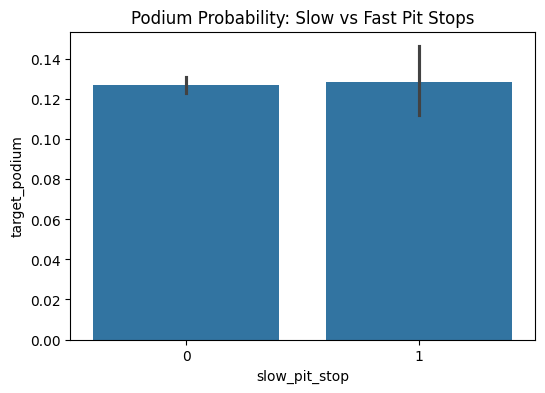

In [57]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=df,
    x="slow_pit_stop",
    y="target_podium",
    errorbar="ci"
)
plt.title("Podium Probability: Slow vs Fast Pit Stops")
plt.show()

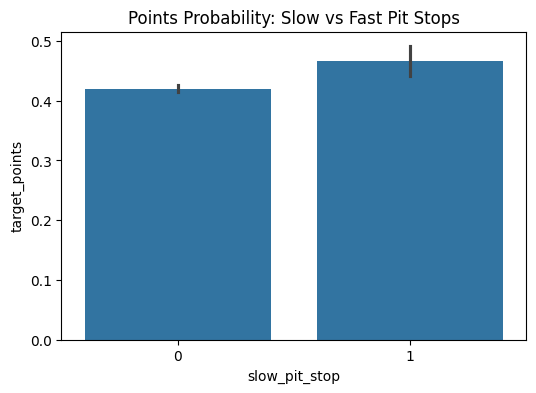

In [58]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=df,
    x="slow_pit_stop",
    y="target_points",
    errorbar="ci"
)
plt.title("Points Probability: Slow vs Fast Pit Stops")
plt.show()

## Save Outputs

Save model comparison tables for use in reporting and downstream documentation.

In [59]:
glm_results.to_csv("data_processed/classification_glm_results.csv", index=False)
model_compare.to_csv("data_processed/points_finish_model_comparison.csv", index=False)

## Summary Insights

- Starting position remains the strongest predictor of race outcomes
- Logistic regression provides strong baseline performance across multiple targets
- Model calibration confirms that predicted probabilities are reliable
- Tree-based methods do not substantially outperform simpler models
- Pit stop performance introduces measurable variation in podium outcomes

Overall, the classification models reinforce that Formula 1 outcomes are highly structured, with much of the predictive signal available before the race begins.